# **1. Introduction**

This notebook interprets the best model from **Notebook 03** (Tuned XGBoost) and draws practical conclusions from the full project.

### Sections:
1. Load model and data
2. Feature importance — what the model relies on most
3. SHAP values — explaining individual predictions (XAI)
4. Business implications
5. Model limitations
6. How to improve
7. Final conclusion

# **2. Import Libraries & Load Model**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project'
processed_dir = os.path.join(BASE, 'data', 'processed')

# Load processed data
X_train = pd.read_csv(os.path.join(processed_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(processed_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(processed_dir, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(processed_dir, 'y_test.csv')).squeeze()

# Load best model
model = joblib.load(os.path.join(BASE, 'models', 'xgb_best_model.pkl'))

print('Model and data loaded.')
print(f'X_test shape: {X_test.shape}')

Model and data loaded.
X_test shape: (6000, 25)


# **3. Feature Importance**

XGBoost assigns an importance score to each feature based on how often and how much it improved splits across all trees. This tells us which features the model relied on most globally — across all 6,000 test predictions.

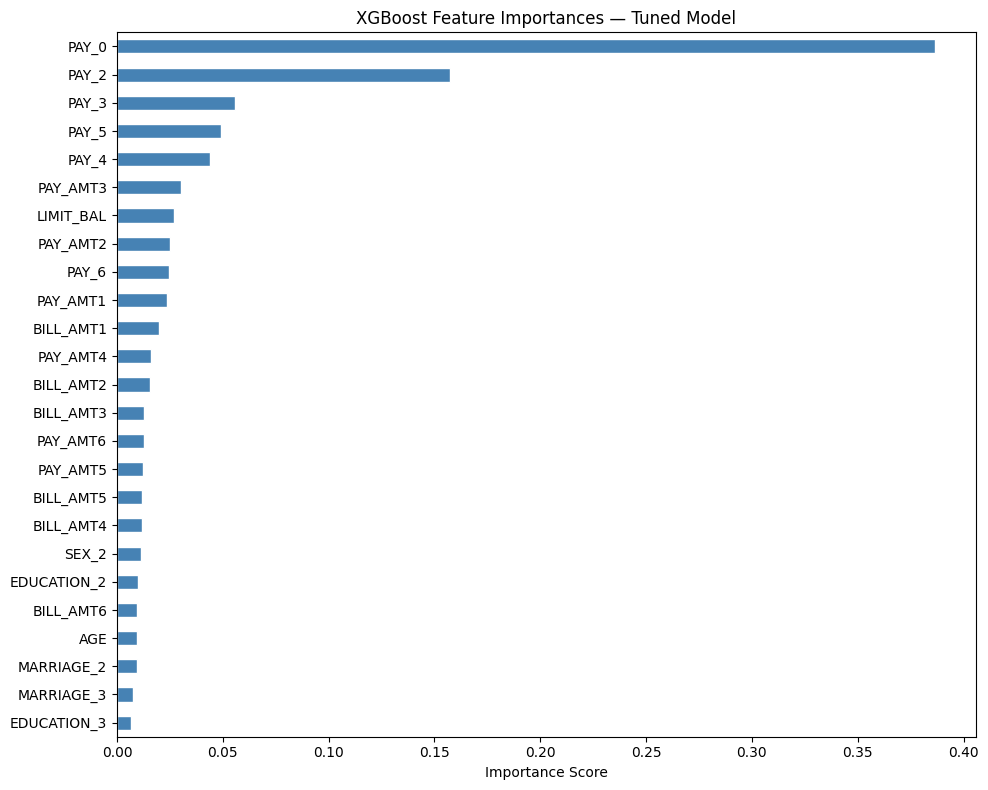

Top 10 features:
PAY_0        0.3864
PAY_2        0.1573
PAY_3        0.0559
PAY_5        0.0491
PAY_4        0.0441
PAY_AMT3     0.0303
LIMIT_BAL    0.0272
PAY_AMT2     0.0248
PAY_6        0.0247
PAY_AMT1     0.0236
dtype: float32

Bottom 5 features (least useful):
BILL_AMT6      0.0095
AGE            0.0094
MARRIAGE_2     0.0094
MARRIAGE_3     0.0075
EDUCATION_3    0.0069
dtype: float32


In [4]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importances — Tuned Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.sort_values(ascending=False).head(10).round(4))
print('\nBottom 5 features (least useful):')
print(importances.sort_values(ascending=False).tail(5).round(4))

# **4. SHAP Values — Explainable AI (XAI)**

Feature importance tells us *which* features matter globally, but it doesn't tell us *how* they affect predictions or *why* a specific customer was flagged. SHAP fills that gap.

**What is SHAP?**
SHAP (SHapley Additive exPlanations) is based on game theory. For every single prediction, it calculates how much each feature pushed the prediction *towards* or *away from* default. A positive SHAP value means the feature increased the default probability; a negative value means it decreased it.

**Two levels of explanation:**
- **Global** — average SHAP values across all customers: which features matter most and in which direction
- **Individual** — SHAP values for a single customer: why *this specific person* was predicted to default or not

## **4.1 Global SHAP — Summary Plot**

The summary plot shows every feature and every customer. Each dot is one customer. The colour shows the feature value (red = high, blue = low). The x-axis shows the SHAP value — how much that feature pushed the prediction.

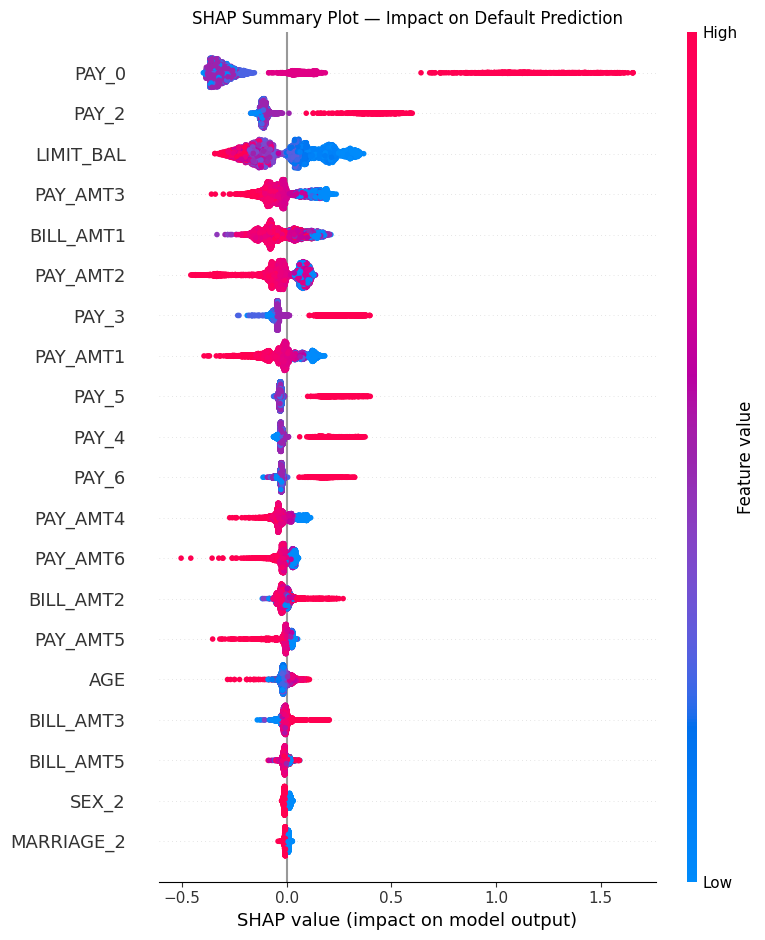

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — Impact on Default Prediction')
plt.tight_layout()
plt.show()

## **4.2 Individual SHAP — Waterfall Plots**

A waterfall plot explains a single prediction. It shows which features pushed the prediction up (towards default) and which pushed it down, starting from the baseline (average model output) and arriving at the final prediction.

We look at two customers:
- One the model **correctly identified as a defaulter**
- One the model **incorrectly missed (false negative)**

=== Correctly Caught Defaulter (True Positive) ===


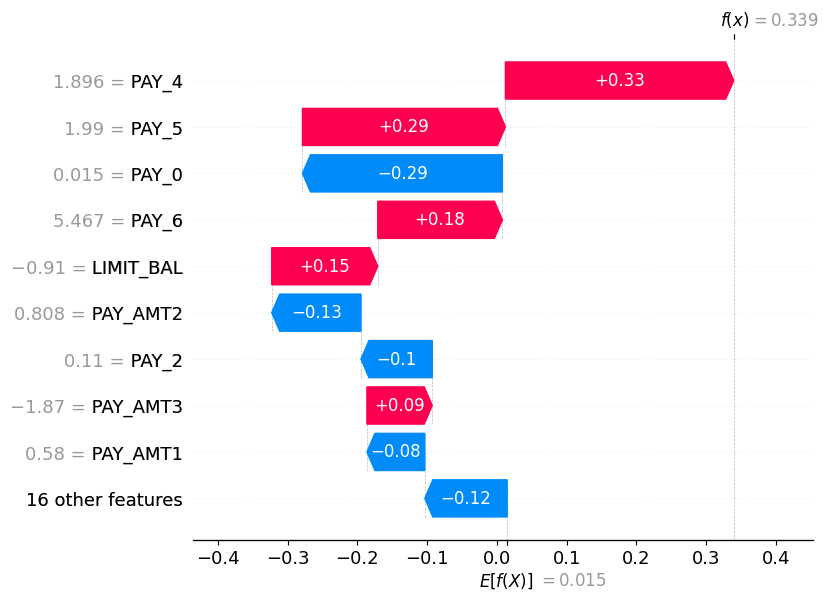

=== Missed Defaulter (False Negative) ===


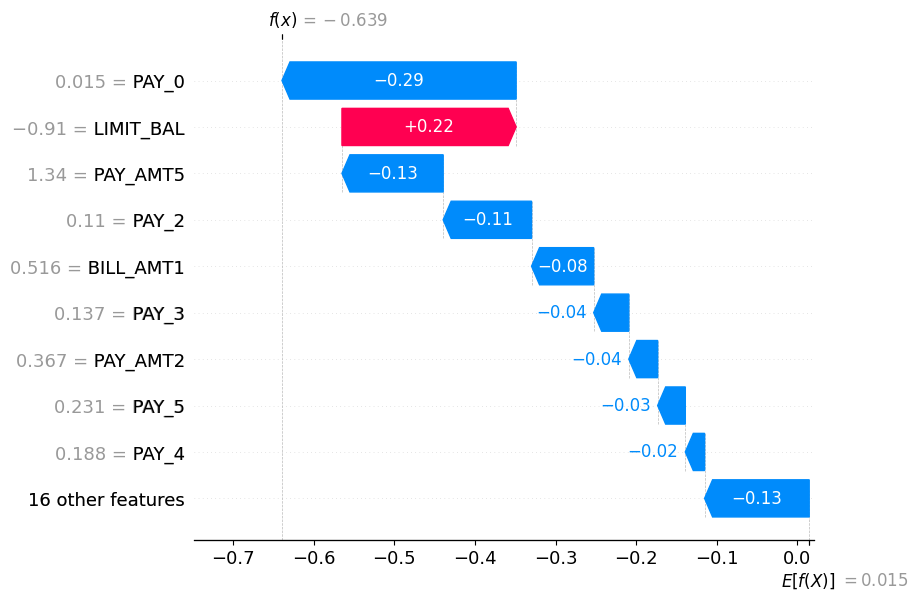

In [6]:
shap_explanation = explainer(X_test)
y_pred_test = model.predict(X_test)
y_test_arr = y_test.values

# Correctly predicted defaulter (TP)
tp_idx = np.where((y_test_arr == 1) & (y_pred_test == 1))[0][0]

# Missed defaulter (FN)
fn_idx = np.where((y_test_arr == 1) & (y_pred_test == 0))[0][0]

print('=== Correctly Caught Defaulter (True Positive) ===')
shap.plots.waterfall(shap_explanation[tp_idx], show=True)

print('=== Missed Defaulter (False Negative) ===')
shap.plots.waterfall(shap_explanation[fn_idx], show=True)

# **5. Business Implications**

### What the model tells us:

**Payment status is everything.** PAY_0 alone drives 39% of all predictions. A customer who has delayed payment by 2+ months is dramatically more likely to default next month. This is actionable — the bank can trigger early intervention (payment reminders, restructuring offers) the moment a customer misses a payment.

**Credit limit is a proxy for creditworthiness.** Lower credit limits correlate with higher default risk (r = -0.15). This makes intuitive sense — the bank assigned lower limits to customers it already assessed as higher risk when the account was opened.

**Bill amounts matter less than how you pay.** The BILL_AMT columns barely appear in the top features. It's not how much you owe — it's whether you're paying it.

### Practical deployment considerations:

- **Threshold tuning:** The default 0.5 threshold is not optimal for this use case. A bank would lower the threshold (e.g. 0.35) to catch more defaulters at the cost of more false alarms — the right balance depends on the cost of a missed default vs. the cost of incorrectly denying credit to a good customer.
- **Model monitoring:** Customer behaviour changes over time. The model should be retrained periodically as new data becomes available.
- **Regulatory compliance:** In many countries, credit decisions require explainability. The SHAP waterfall plots provide exactly this — a human-readable explanation for why a specific customer was flagged.

# **6. Model Limitations**

**Data limitations:**
- Only 6 months of payment history. Real credit models use years of behaviour — a customer who defaulted 3 years ago but has been clean since is indistinguishable from a lifelong reliable payer.
- No external bureau data (credit scores, total debt across all lenders, number of open accounts). This is the single biggest gap — bureau data alone would likely push AUC above 0.85.
- No behavioural or transactional data (spending categories, cash withdrawals, online vs. in-store). These are strong predictors used by modern fintech credit models.

**Model limitations:**
- Missed defaulters (37.6% miss rate) tend to be customers who appeared financially stable up until the point of default — job loss, medical emergency, or other sudden life events are fundamentally unpredictable from historical payment data.
- Precision is weak (~0.47) — roughly half of flagged customers are actually fine. A production system would need careful threshold calibration to manage the cost of false alarms.
- The model is a snapshot. Customer behaviour drifts over time — economic downturns, interest rate changes, and demographic shifts can erode model performance if it is not retrained.

# **7. How to Improve**

With the current dataset, there are several legitimate ways to push performance further:

### Feature Engineering (highest impact)
Creating new features from existing columns often reveals stronger signals than the raw columns alone:

```python
# Credit utilisation — how much of their limit are they using?
df['utilisation'] = df['BILL_AMT1'] / df['LIMIT_BAL']

# Payment ratio — are they paying the full bill or just the minimum?
df['pay_ratio_1'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)

# Payment trend — is their situation getting worse over 6 months?
df['pay_trend'] = df['PAY_0'] - df['PAY_6']  # positive = deteriorating

# Total outstanding balance vs total paid
df['total_bill'] = df[bill_cols].sum(axis=1)
df['total_paid'] = df[pay_amt_cols].sum(axis=1)
df['net_balance'] = df['total_bill'] - df['total_paid']
```

### Threshold Optimisation
The default 0.5 threshold is arbitrary. Plotting the Precision-Recall curve and selecting a lower threshold (e.g. 0.35) would significantly improve recall with an acceptable precision trade-off — the right balance depends on the business cost of each type of error.

### Model Ensembling (stacking)
Combining multiple models into a meta-model captures complementary patterns:
```
Logistic Regression ─┐
Random Forest       ─┤─→ Meta model → final prediction
XGBoost Tuned       ─┘
```
Typically gains 1–2% AUC over the best single model.

### Bayesian Hyperparameter Optimisation
`RandomizedSearchCV` samples randomly. Bayesian optimisation (e.g. `optuna`, `hyperopt`) learns which areas of the parameter space to explore more — finds better parameters in fewer iterations.

### Realistic Expected Gains

| Improvement | Likely AUC gain |
|-------------|----------------|
| Feature engineering | +0.02 to +0.04 |
| Threshold optimisation | No AUC gain, but better recall/precision trade-off |
| Stacking | +0.01 to +0.02 |
| Bayesian tuning | +0.00 to +0.01 |

**The ceiling of this dataset is approximately 0.82–0.84 AUC.** Beyond that, additional external data (bureau, transactions) would be required.

# **8. Final Conclusion**

### Project Summary

This project built a full end-to-end credit default prediction pipeline on the UCI Credit Card dataset (30,000 customers, 25 features).

| Notebook | What was done |
|----------|--------------|
| 01 — EDA | Explored the data, identified imbalance (22% default), key predictors, skewed distributions, and undocumented categories |
| 02 — Preprocessing | Cleaned, log-transformed, encoded, split and scaled the data with no data leakage |
| 03 — Modelling | Trained 3 models, compared, tuned, evaluated, and performed error analysis |
| 04 — Interpretation | Explained predictions globally and individually using SHAP, drew business conclusions |

### Final Model Performance (Tuned XGBoost — Test Set)

| Metric | Score |
|--------|-------|
| AUC-ROC | **0.7805** |
| Recall | 0.6240 |
| Precision | 0.4670 |
| F1 Score | 0.5342 |

### Key Takeaways

1. **Payment behaviour dominates.** PAY_0 alone explains 39% of model predictions. Recent payment delays are by far the strongest signal — consistent across EDA, feature importance, and SHAP analysis.

2. **Simple models are competitive.** Logistic Regression achieved 0.7459 AUC and 0.615 recall — barely behind the tuned XGBoost. This is a sign the data, not the model, is the bottleneck.

3. **The hard cases are invisible.** Customers who defaulted despite appearing financially stable (on-time payments, higher credit limits) represent the 37.6% miss rate. These are fundamentally unpredictable from payment history alone.

4. **Explainability is achievable.** SHAP values provide customer-level explanations that satisfy both analytical and regulatory requirements — making this model deployable in principle.

5. **Results are honest and competitive.** AUC-ROC of 0.78 is consistent with published literature on this exact dataset using standard ML approaches. Results are not inflated.